patients in file: 235
                Modality  Available  Missing  Available_Percentage  \
0       Overall survival        234        1             99.574468   
2         RNA sequencing        175       60             74.468085   
3            Genomic/WES        136       99             57.872340   
1  Clinical/pathological         97      138             41.276596   
4            Methylation         56      179             23.829787   

   Missing_Percentage  
0            0.425532  
2           25.531915  
3           42.127660  
1           58.723404  
4           76.170213  


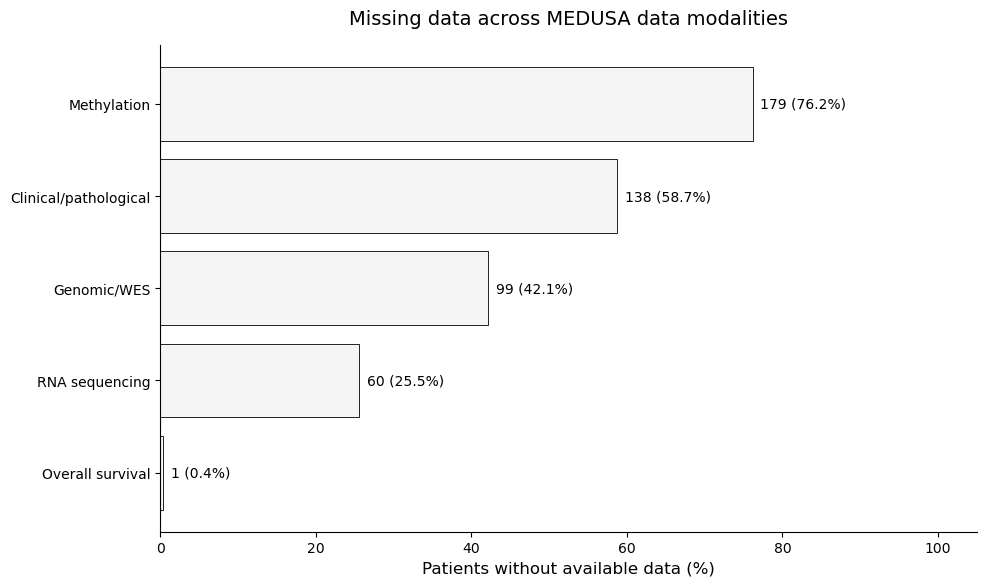

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# same figure as before but now it actually reads the real file and counts
# the missing values itself instead of me typing the numbers in by hand.
# that way if the data changes i don't have to remember to update anything.

raw_path = "/home/rt334/Downloads/MEDUSA_Master_Dataset_UPDATED.csv"
output_dir = Path("/home/rt334/Independent/Hermes/MEDUSA_figures")
output_dir.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

# loading and cleaning the raw file
# the raw master csv has two extra rows at the bottom (MEDDESCRIPTION and
# MEDFEATURE) that hold the real column names, and everything reads in as
# text because of that. need to sort both out before counting anything.

df = pd.read_csv(raw_path, low_memory=False)
id_col = "MEDUSA_Subject_ID"

desc_row = df[df[id_col] == "MEDDESCRIPTION"]
if len(desc_row) > 0:
    desc_row = desc_row.iloc[0]
    rename_map = {c: desc_row[c] for c in df.columns
                  if c != id_col and pd.notna(desc_row[c]) and desc_row[c] != c}
    df = df.rename(columns=rename_map)

df = df[~df[id_col].astype(str).isin(["MEDDESCRIPTION", "MEDFEATURE"])].copy()

total_patients = len(df)
print(f"patients in file: {total_patients}")

# quick check - make sure there's no literal "NA" text hiding in the data
# that pandas didn't catch as a real missing value on read-in
for col in ["Age", "Overall survival (Surgery-to-Death) in days"]:
    if col in df.columns:
        weird = df[col].astype(str).str.strip().str.upper()
        n_literal_na = (weird == "NA").sum()
        if n_literal_na > 0:
            print(f"WARNING: found {n_literal_na} literal 'NA' strings in {col}, these need fixing")

# this works out real availability per modality 
# columns chosen to represent each modality - same ones used in the earlier
# data availability table

modality_cols = {
    "Overall survival": "Overall survival (Surgery-to-Death) in days",
    "Clinical/pathological": "Age",
    "RNA sequencing": "ssGSEA:HALLMARK_ADIPOGENESIS",
    "Genomic/WES": "Mutation BAP1",
    "Methylation": "ageAcc.Horvath",
}

rows = []
for label, col in modality_cols.items():
    if col not in df.columns:
        print(f"couldn't find column '{col}' for {label} - skipping")
        continue
    available = df[col].notna().sum()
    rows.append({"Modality": label, "Available": available})

modality_data = pd.DataFrame(rows)
modality_data["Missing"] = total_patients - modality_data["Available"]
modality_data["Available_Percentage"] = modality_data["Available"] / total_patients * 100
modality_data["Missing_Percentage"] = modality_data["Missing"] / total_patients * 100

modality_data = modality_data.sort_values("Missing_Percentage", ascending=True)

print(modality_data)

# plotting the bar chart
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    modality_data["Modality"],
    modality_data["Missing_Percentage"],
    color="whitesmoke",
    edgecolor="black",
    linewidth=0.6
)

for bar, missing_count, missing_percentage in zip(
    bars, modality_data["Missing"], modality_data["Missing_Percentage"]
):
    ax.text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{missing_count} ({missing_percentage:.1f}%)",
        va="center",
        fontsize=10
    )

ax.set_title("Missing data across MEDUSA data modalities", pad=15)
ax.set_xlabel("Patients without available data (%)")
ax.set_ylabel("")
ax.set_xlim(0, 105)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(output_dir / "Figure_1_missing_data_by_modality.png", dpi=600, bbox_inches="tight")
plt.show()

     Histology  Patients  Percentage
0  Epithelioid        88   90.721649
1     Biphasic         8    8.247423
2  Sarcomatoid         1    1.030928


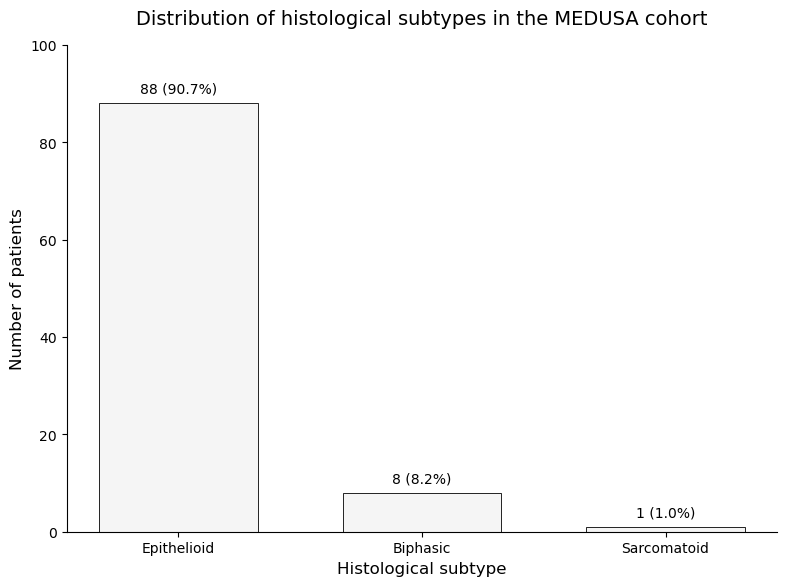

In [12]:
# importing the relevant libraries 
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# working directory and creating a new one

raw_path = "/home/rt334/Downloads/MEDUSA_Master_Dataset_UPDATED.csv"
output_dir = Path("/home/rt334/Independent/Hermes/MEDUSA_figures")
output_dir.mkdir(parents=True, exist_ok=True)

# loading and cleaning, same as the other figures 
df = pd.read_csv(raw_path, low_memory=False)
id_col = "MEDUSA_Subject_ID"

desc_row = df[df[id_col] == "MEDDESCRIPTION"]
if len(desc_row) > 0:
    desc_row = desc_row.iloc[0]
    rename_map = {c: desc_row[c] for c in df.columns
                  if c != id_col and pd.notna(desc_row[c]) and desc_row[c] != c}
    df = df.rename(columns=rename_map)

df = df[~df[id_col].astype(str).isin(["MEDDESCRIPTION", "MEDFEATURE"])].copy()
df["Histology"] = pd.to_numeric(df["Histology"], errors="coerce")

# NOTE: histology coding (1/2/3) is inferred, not confirmed against a real
# codebook yet - matched it against an earlier subtype comparison table and
# it lines up, but worth double checking with whoever gave me the data
histology_map = {1.0: "Epithelioid", 2.0: "Sarcomatoid", 3.0: "Biphasic"}
df["Histology_label"] = df["Histology"].map(histology_map)

counts = df["Histology_label"].value_counts()
histology_data = pd.DataFrame({
    "Histology": counts.index,
    "Patients": counts.values
})
# keep a consistent order for the plot rather than whatever value_counts gives
order = ["Epithelioid", "Biphasic", "Sarcomatoid"]
histology_data["Histology"] = pd.Categorical(histology_data["Histology"], categories=order, ordered=True)
histology_data = histology_data.sort_values("Histology")

histology_total = histology_data["Patients"].sum()
histology_data["Percentage"] = histology_data["Patients"] / histology_total * 100

print(histology_data)

# plotting the vertical bar chart 
fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(
    histology_data["Histology"],
    histology_data["Patients"],
    color="whitesmoke",
    edgecolor="black",
    linewidth=0.6,
    width=0.65
)

for bar, count, percentage in zip(bars, histology_data["Patients"], histology_data["Percentage"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1.5,
        f"{count} ({percentage:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=10
    )

ax.set_title("Distribution of histological subtypes in the MEDUSA cohort", pad=15)
ax.set_xlabel("Histological subtype")
ax.set_ylabel("Number of patients")
ax.set_ylim(0, 100)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(output_dir / "Figure_2_histology_distribution.png", dpi=600, bbox_inches="tight")
plt.show()